In [1]:
from get_vibration_data import get_vibration_data
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from fem_model import MeshInvariantDiffusion_ver2
from tqdm import tqdm
import json
from utils import draw_disp_on_mesh,draw_mesh,inverse_standard_scale
import pandas as pd
from fem_dataset_standard_scaler_full_mesh_diffusion import FemGraphInferenceDataset
import numpy as np
import matplotlib.pyplot as plt


In [2]:
sample_num=0
Lx=6
Ly=2
Lz=2
nx=16
ny=18
nz=10
xm0  = 0.9972
xm1= xm0+Lx/nx*2
ym0= 0.36
ym1 = ym0+Ly/ny*2
zm0= 0
zm1 = zm0+Lz/nz*2
E =6.9e10
nu = 0.33
rho = 2700
m_add=31
freq=262
a_base=15
zeta= 0.005



In [3]:
xyz,disp,df_cells,FRF=get_vibration_data(sample_num,Lx,Ly,Lz,nx,ny,nz,xm0,xm1,ym0,ym1,zm0,zm1,E,nu,rho,m_add,freq,a_base,zeta)

Number of converged eigenpairs 470
saved: nodal_stress_disp.csv
saved: edge_infos.csv
saved: params.txt


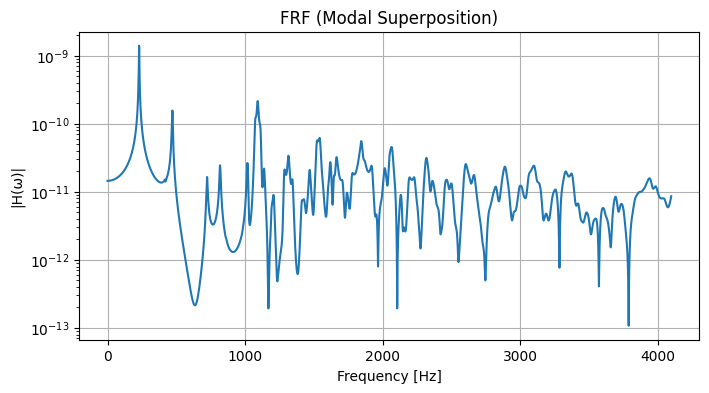

In [4]:
plt.figure(figsize=(8,4))
plt.semilogy(FRF[0], FRF[1])
plt.xlabel("Frequency [Hz]")
plt.ylabel("|H(ω)|")
plt.title("FRF (Modal Superposition)")
plt.grid(True)
plt.show()

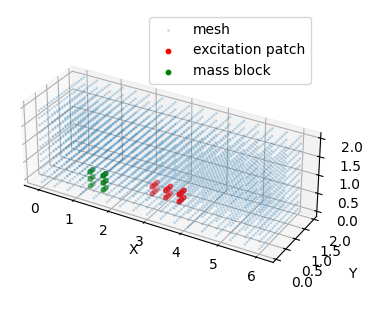

In [5]:
draw_mesh(xyz.values[:,0],xyz.values[:,1],xyz.values[:,2],Lx,Ly,Lz,nx,ny,nz,xm0,xm1,ym0,ym1,zm0,zm1)

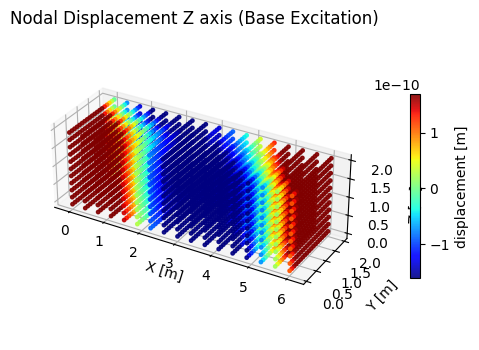

In [6]:
draw_disp_on_mesh(xyz.values[:,0],xyz.values[:,1],xyz.values[:,2],disp.values[:,2])

In [24]:
def collate_mesh_batch(batch):
    pos   = torch.cat([b["pos"]  for b in batch], dim=0)
    cond  = torch.cat([b["cond"] for b in batch], dim=0)

    batch_idx = torch.cat([
        torch.full((b["pos"].size(0),), i, dtype=torch.long)
        for i, b in enumerate(batch)
    ])
    #print(batch_idx)
    return {
        "pos": pos,         # [ΣNi,3]
        "cond": cond,       # [ΣNi,Cc]
        "batch": batch_idx  # [ΣNi]
    }


@torch.no_grad()
def sample_mesh(model, pos, cond, sched):
    """
    pos  : [N,3]   (새 mesh)
    cond : [N,Cc]
    """
    device = pos.device
    N, Co = pos.size(0), model.fc_out.out_features

    x = torch.randn(N, Co, device=device)
    batch = torch.zeros(N, dtype=torch.long, device=device)  # single mesh

    for t in reversed(range(sched.T//2)):
        t_tensor = torch.tensor([t], device=device)
        eps = model(pos, cond, x, t_tensor, batch)

        alpha = sched.alphas[t]
        ab = sched.alpha_bar[t]
        beta = sched.betas[t]

        x = (1 / torch.sqrt(alpha)) * (
            x - (1 - alpha) / torch.sqrt(1 - ab) * eps
        )

        if t > 0:
            x += torch.sqrt(beta) * torch.randn_like(x)

    return x


def split_batch_by_mesh(batch):
    """
    batch:
      pos   [N,3]
      cond  [N,Cc]
      x0    [N,Co]
      batch [N]
    """
    meshes = []
    batch_idx = batch["batch"]

    for m in batch_idx.unique():
        mask = batch_idx == m
        meshes.append({
            "pos":  batch["pos"][mask],
            "cond": batch["cond"][mask],
        })
    return meshes



class DiffusionScheduler:
    def __init__(self, T=1000, device="cpu"):
        self.T = T
        self.betas = torch.linspace(1e-4, 0.02, T, device=device)
        self.alphas = 1.0 - self.betas
        self.alpha_bar = torch.cumprod(self.alphas, dim=0)

In [25]:
root = "./test"
if torch.cuda.is_available() :
    device='cuda'
elif torch.backends.mps.is_available() :
    device='mps'
else :
    device='cpu'
file_name="diffustion_ver2_early"
with open(f"model_param_{file_name}.json", "r", encoding="utf-8") as f:
    model_param = json.load(f)

ds = FemGraphInferenceDataset(root_dir=root,scale_info=model_param['dataset_scale_info'])
loader = DataLoader(ds, batch_size=32, shuffle=False, collate_fn=collate_mesh_batch)

model = MeshInvariantDiffusion_ver2(
    pos_dim=model_param['pos_dim'],
    cond_dim=model_param['cond_dim'],
    out_dim=model_param['out_dim'],
    hidden=model_param['hidden'],
    T= model_param['T'],
    fourier_L=model_param['fourier_L'],
    num_blocks=model_param['num_blocks']
    ).to(device)

checkpoint = torch.load(f"mesh_invariant_{file_name}.pt", map_location=device)
model.load_state_dict(checkpoint)
model.eval()
sched = DiffusionScheduler(device=device)
sched.T=model_param['T']
for batch in loader:
    model.eval()

    batch = {k: v.to(device) for k, v in batch.items()}

    # batch → mesh 단위로 분리
    meshes = split_batch_by_mesh(batch)
    data=[]
    for m in meshes:
        pos  = m["pos"]
        cond = m["cond"]
        x_hat = sample_mesh(model, pos, cond, sched)
        data=np.hstack((pos.cpu().detach().numpy(),x_hat.cpu().detach().numpy()))

Loading FEM graph dataset...


100%|██████████| 1/1 [00:00<00:00, 56.44it/s]

Build Complete FEM graph dataset...


In [26]:

data=pd.DataFrame(data,columns=["x","y","z","uz"])
for col in data.columns:
    data[col]=inverse_standard_scale(data[col].values,model_param['dataset_scale_info'][col]['std'],model_param['dataset_scale_info'][col]['mean'],model_param['dataset_scale_info'][col]['max'])


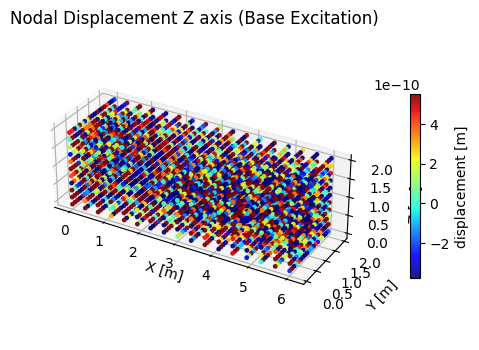

In [27]:
draw_disp_on_mesh(data[['x']].values[:,0],data[['y']].values[:,0],data[['z']].values[:,0],data[['uz']].values[:,0])

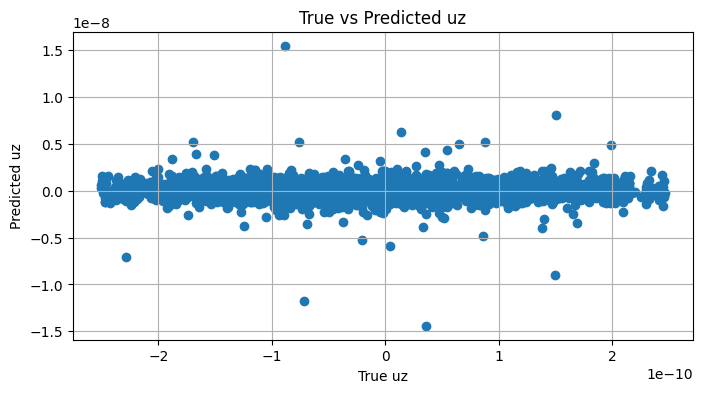

In [29]:
plt.figure(figsize=(8,4))
plt.scatter(disp[['ux']].values.reshape(-1),data[['uz']].values.reshape(-1))
plt.xlabel("True uz")
plt.ylabel("Predicted uz")
plt.title("True vs Predicted uz")
plt.grid(True)
plt.show()